OBJECTIVE

Analyze user journey:
👉 Visit → View Product → Add to Cart → Purchase

Goal:

Identify drop-off points
Improve conversion rate

📊 Columns:
event_type (view, cart, purchase)
product_id
user_id
event_time
category

LOAD DATA

In [1]:
import pandas as pd

df = pd.read_csv("ecomdataDec2019.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3533286 entries, 0 to 3533285
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 242.6+ MB


Data Cleaning 

In [2]:
# Convert time
df['event_time'] = pd.to_datetime(df['event_time'])

# Keep only relevant events
df = df[df['event_type'].isin(['view', 'cart', 'purchase'])]

FUNNEL CALCULATION
Count users at each stage:

In [3]:
funnel = df.groupby('event_type')['user_id'].nunique()

print(funnel)

event_type
cart         83458
purchase     25613
view        358212
Name: user_id, dtype: int64


In [ ]:
CONVERSION RATES

In [4]:
view_to_cart = funnel['cart'] / funnel['view']
cart_to_purchase = funnel['purchase'] / funnel['cart']

print("View → Cart:", view_to_cart)
print("Cart → Purchase:", cart_to_purchase)

View → Cart: 0.23298493629470815
Cart → Purchase: 0.30689688226413286


📊 Insights:
Low View→Cart → product issue
Low Cart→Purchase → checkout issue

In [ ]:
📊 Insights:
Low View→Cart → product issue
Low Cart→Purchase → checkout issue

In [5]:
drop_off_view = 1 - view_to_cart
drop_off_cart = 1 - cart_to_purchase

print("Drop-off at View stage:", drop_off_view)
print("Drop-off at Cart stage:", drop_off_cart)

Drop-off at View stage: 0.7670150637052918
Drop-off at Cart stage: 0.6931031177358671


📊 Insight:

👉 Identify biggest loss point

TOP PRODUCTS ANALYSIS

In [6]:
top_products = df[df['event_type']=='purchase']['product_id'].value_counts().head(10)

print(top_products)

product_id
5809910    1659
5854897     786
5802432     714
5700037     621
5809912     620
5833330     594
5304        549
5751422     548
5815662     521
5751383     435
Name: count, dtype: int64


📊 Insight:
Best-selling products
Revenue drivers

TIME ANALYSIS

<Axes: xlabel='hour'>

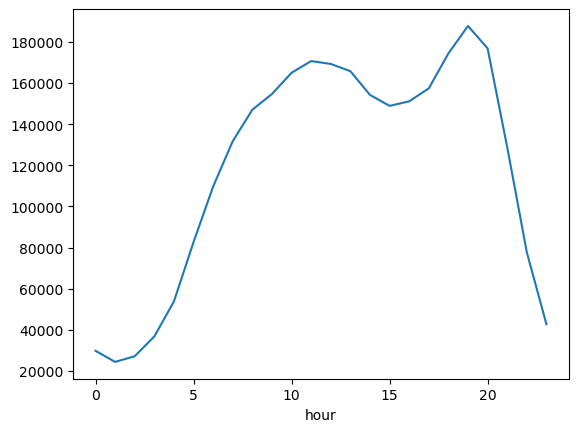

In [7]:
df['hour'] = df['event_time'].dt.hour

hourly = df.groupby('hour')['user_id'].count()

hourly.plot(kind='line')

📊 Insight:
Peak shopping hours
Best time for ads

VISUALIZE FUNNEL

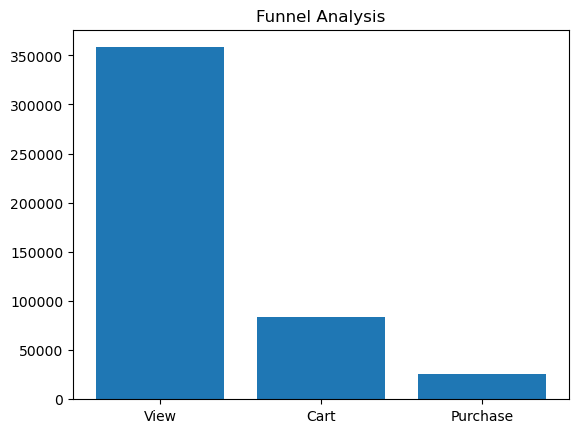

In [8]:
import matplotlib.pyplot as plt

stages = ['View', 'Cart', 'Purchase']
values = [funnel['view'], funnel['cart'], funnel['purchase']]

plt.bar(stages, values)
plt.title("Funnel Analysis")
plt.show()

📊 Insight:
Clear funnel drop visualization

📊 Key Findings:
Significant drop-off between view and cart stage
Conversion rate decreases sharply before purchase
Few products drive majority of sales
Peak activity observed during specific hours

💼 BUSINESS RECOMMENDATIONS
Improve product pages (images, pricing, reviews)
Simplify checkout process
Offer discounts to cart users
Run ads during peak hours